In [1]:

import math
import os
import random
import sys

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from src import *

plt.rcParams.update({'font.size': 18})

# Generating Faulty Predictions

The PyKAN trained in 3.1 is here loaded and used to generate predictions over the entire dataset.

## Load dataset

The entire dataset is standardized using the mean and the std of the train set that was saved by the previous notebook after the training.

In [2]:
# 1s
train_x, train_y = read_dataset(stage='classification')
valid_x = read_dataset(stage='classification', dataset='valid')
test_x = read_dataset(stage='classification', dataset='test')

# Load the means and standard deviations of the train set used to train the model
norm = pd.read_csv('results/one_time_train_norm.csv').iloc[0]
means = norm[[f'{col}_mean' for col in train_x.columns]].values
stds = norm[[f'{col}_std' for col in train_x.columns]].values
means, stds = torch.tensor(means, dtype=torch.float32), torch.tensor(stds, dtype=torch.float32)

Note: Do not confuse the `trainset_x`/`testset_x` with the test set selected using holdout in the training phase. Here by `testset_x` I refer to the merging of the unlabelled validation and test sets of the challenge. Therefore, it should come as no surprise that *I standardize both using the sample mean and standard deviation of the test set selected with holdout during training*.

In [3]:
trainset_x = torch.tensor(train_x.values, dtype=torch.float32)
validset_x = torch.tensor(valid_x.values, dtype=torch.float32)
testset_x = torch.tensor(test_x.values, dtype=torch.float32)
trainset_x = (trainset_x - means) / stds
validset_x = (validset_x - means) / stds
testset_x = (testset_x - means) / stds

Let's load the MultiKAN, having greater accuracy over the simpler PyKAN with no multiplication nodes.

In [6]:
pyKAN: PHMNetwork = PyKAN([[len(train_x.columns), 0], [1, 1], [1, 0]], 'classification', grid_size=2,
                          device='cpu')

checkpoint directory created: ./model
saving model version 0.0


In [7]:
# 2s
pyKAN.load('fault_detection')
_, _, testset, _ = split_dataset(train_x, train_y['faulty'], train_ratio=0.15, standardize_y=False, max=1, seed=1)
metrics = pyKAN.test(testset)
assert metrics['avg_test_score'] > 0.8
pd.DataFrame([metrics])

100%|██████████| 39/39 [00:02<00:00, 15.86it/s]


,test_loss,avg_test_score,accuracy,precision,recall,f1,cm
0,0.081681,0.929023,0.97886,0.970797,0.977016,0.973897,"[[184480, 3744], [2928, 124464]]"


In [8]:
def predict(model, dataset, batch_size=8192) -> pd.DataFrame:
    model.eval()
    predictions = []

    with torch.no_grad():
        for i in range(math.ceil(dataset.size(0) / batch_size)):
            x = dataset[i * batch_size:min(dataset.size(0), (i + 1) * batch_size)]
            confidence = torch.sigmoid(model(x).view(-1))
            predictions.extend(confidence.detach().numpy().tolist())
    return pd.DataFrame({'faulty': predictions})

In [9]:
# 3s
pred_train = predict(pyKAN, trainset_x)
pred_valid = predict(pyKAN, validset_x)
pred_test = predict(pyKAN, testset_x)

## Visualizing the model's output
Just to make it easier to understand the performance of the model, the next cell randomly selects some subsequent samples and plots the model's prediction against the ground truth.

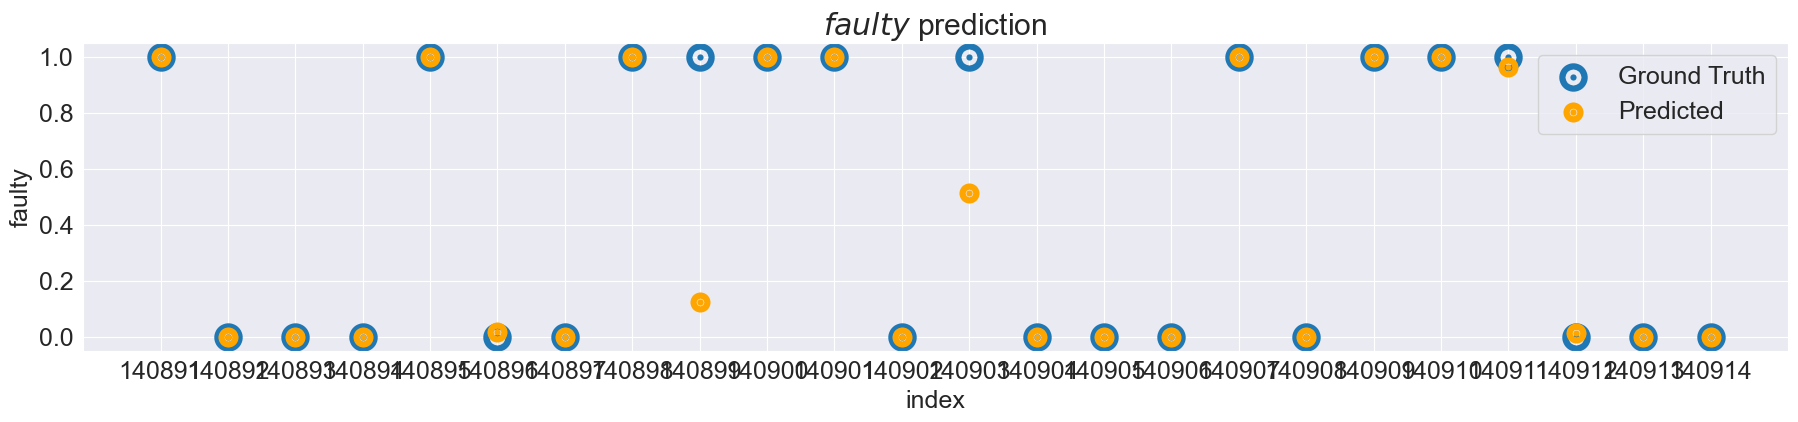

In [10]:
# 1s
LENGTH = 24
train_y['index'] = range(len(train_y))
pred_train['index'] = range(len(pred_train))
i = random.randint(0, len(train_y) - LENGTH)
ax = train_y[i:i + LENGTH].plot(kind='scatter', x='index', y='faulty', figsize=(22, 4), linewidth=16,
                                label='Ground Truth')
pred_train[i:i + LENGTH].plot(kind='scatter', x='index', y='faulty', ax=ax, color='orange', linewidth=10,
                              label='Predicted')
ax.legend()
ax.minorticks_on()
ax.set_xticks(range(i, i + LENGTH))
ax.set_title('$faulty$ prediction')
plt.show()
pred_train.drop(columns=['index'], inplace=True)

In [11]:
# 1s
pred_train.to_csv('predictions_train.csv', index=False)
pred_valid.to_csv('predictions_valid.csv', index=False)
pred_test.to_csv('predictions_test.csv', index=False)